Name :  Nitesh Ramesh Morem  ,  Kashif Riyaz 

Date : ***20/07/2025***

Email : ***n.morem@oth-aw.de*** , ***k.kashif-riyaz@oth-aw.de***

Dep  :  ***MAI***

## Procedure for Data Recording

We used Python script logger.py to record the data using Arduino BLE rev2 sense using the library BMI_270_BMI_150 which is a library to access Acceleration sensor, gyroscope sensorand Mangnetometer sensor; which recors all three axis X,Y,Z.


We recorded the data by placing the arduino board in trousers pocket as instructed and keept the usb facing upward outside the pocket and then ran the pyhton logger.py script and recorded the movement(imu.csv data). there is also another script for recording Rssi values. both were recorded at the same time parallely in different terminals at the same time.The incosnsitent samples were poped where were very few around 3 to 4 samples of start and end were adjusted such that they have same number os samples in both rssi and logger.py script.



+ To understand the workFlow please folow this link to out Miro Board which shows our workFlow

https://miro.com/app/board/uXjVIgh2pSA=/


Why both cannot be recorded at the same time?
The the samping rate cannot be maintained and it drops to 20hz when we record rsssi for 2 or more devices along with the imu data was not possible with a single script. As the sampling rate is important for the prject as menitioned to maintained aprx 50hz.
Due to this we have used this appraoch.

 

> The Original Floor plan Details

The data was recorded in the Studenten wohnheim eisberg which is near OTH amber hochschule in the ground floor. We also made ***3D model of floor plan*** with iphone. 
To see the floor plan visit this link  :  https://poly.cam/capture/5C864D8B-93F6-4897-B6A5-A658D38C32E6. The actual floor plan is little different and was modified for privacy purposes. Using this we can get the measurements which we later used in the code below.

 

In [1]:
# Only run this cell if u dont have al the required libraries (by uncommenting the below line)

# !pip install pandas matplotlib scipy pygame numpy opencv-python


In [10]:
# These are the dependencies which are required for the project

import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pygame
import numpy as np
import cv2
from scipy.stats import norm
import math
from scipy.ndimage import gaussian_filter1d


In [11]:
# The data into dataframes in pandas

df_1= pd.read_csv('imu.csv')
df_2= pd.read_csv('rssi.csv')
 

In [12]:
#checking the rssi values

df_2['rssi_1'].describe()

count    4550.000000
mean      -82.093626
std         6.334907
min       -90.000000
25%       -87.000000
50%       -84.000000
75%       -79.000000
max       -62.000000
Name: rssi_1, dtype: float64

In [13]:
df_1.head()

,Time_1,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,acc,direction_change
0,-0.000946,-0.240101,1.278342,8.767268,-0.094676,-0.105121,0.063568,-22.928284,-31.260780,49.016754,8.863227,0
1,0.018955,0.186812,1.154549,10.357112,-0.010276,0.058717,0.064260,-24.058014,-36.394737,52.931427,10.422939,0
2,0.038855,-0.021405,1.144670,9.345366,-0.082247,-0.053144,0.076052,-26.273254,-38.539162,54.082184,9.415232,0
3,0.058756,0.057480,1.031954,9.830807,-0.065829,0.027651,0.071734,-26.104797,-33.522102,50.422668,9.884988,0
4,0.078657,0.004042,1.005908,9.421109,-0.092545,-0.004357,0.068726,-22.338776,-35.564644,51.807343,9.474659,0


In [14]:
df_2

,rssi_1,rssi_2,distance_rssi_1,distance_rssi_2
0,-67,-79,1.809218,6.360098
1,-67,-79,1.811034,6.362387
2,-67,-79,1.812828,6.364666
3,-67,-79,1.814599,6.366934
4,-67,-79,1.816348,6.369190
...,...,...,...,...
4545,-63,-84,1.807315,3.488052
4546,-63,-84,1.801983,3.494208
4547,-63,-84,1.796642,3.500392
4548,-63,-84,1.791293,3.506603


The sensor processing was done in another file in ---->> sensorprocessing.ipynb file in the same directory and below is the use case 

### Absolute heading using magnitometer

#   Heading Estimation and Direction Change Visualization

This section calculates the absolute heading using magnetometer readings and visualizes smooth heading trends alongside direction change events.

In [15]:
# we made thhis Function to compute compass heading (0–360°) from magnetometer X and Y
def absolute_heading(x, y):
    radians = np.arctan2(y, x)
    degree = np.degrees(radians)
    degree = np.where(degree < 0, degree + 360, degree)  # Ensure angle is in [0, 360)
    return degree

# Apply heading calculation using the function
df_1['theta'] = absolute_heading(df_1['mag_x'], df_1['mag_y'])

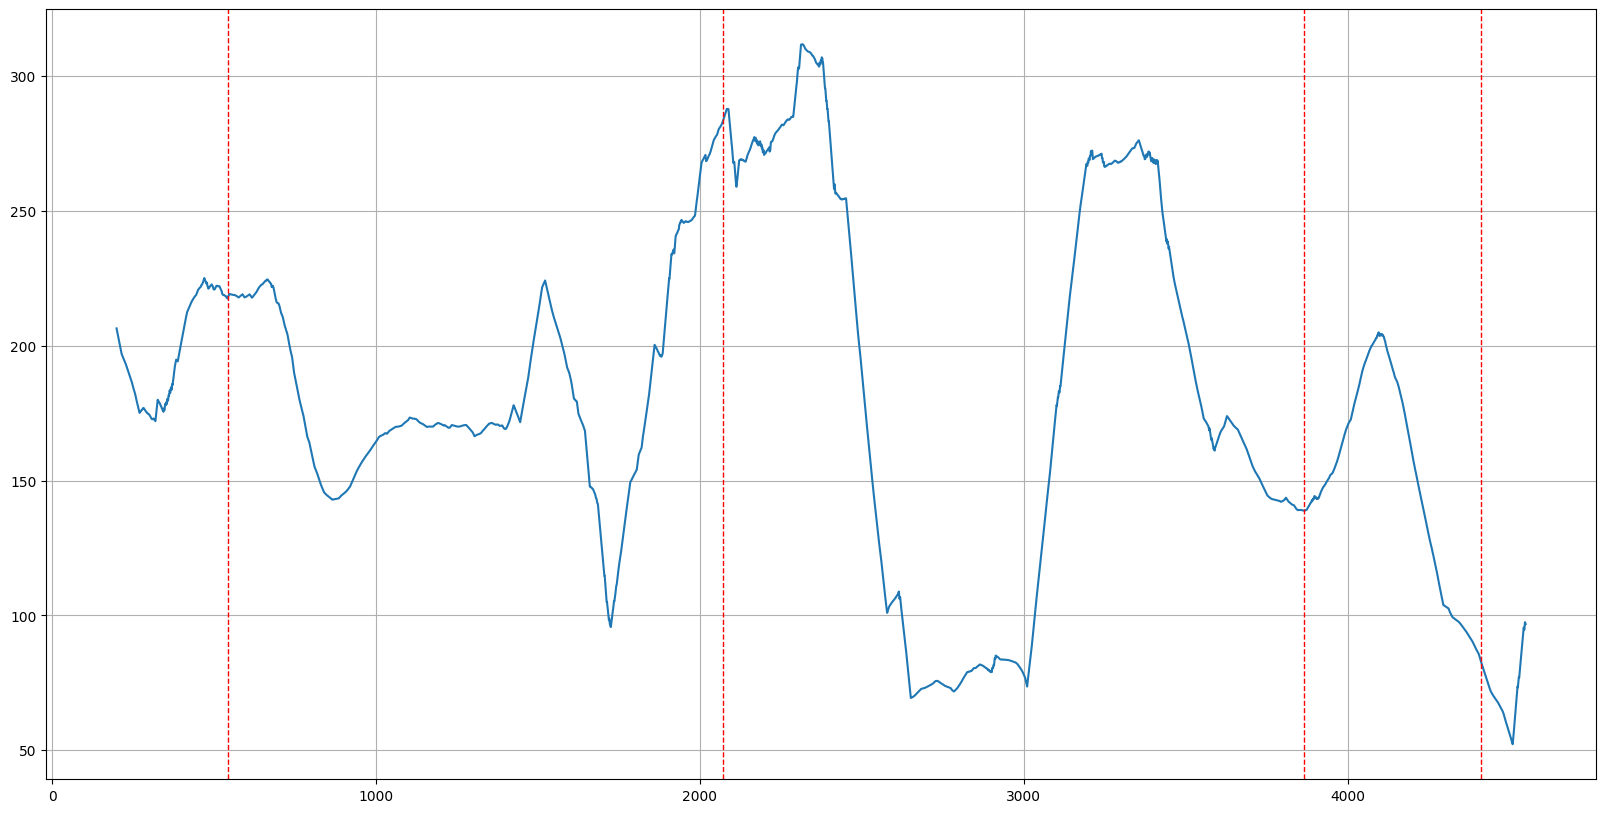

In [16]:

# Smooth the heading to reduce noise using a rolling average
df_1['smooth_theta'] = df_1['theta'].rolling(window=200).mean()

# Plot the smoothed heading and mark direction changes we did this for our understanding of our turns and to keep track of the turns
fig, ax = plt.subplots(figsize=(20, 10))
positions = df_1.index[df_1['direction_change'] == 1]  # Indices where direction changed
plt.plot(df_1['smooth_theta'])
for value in positions:
    ax.axvline(x=value, color='red', linestyle='--', linewidth=1)
plt.grid()
plt.show()

> smooth theta values are not correct i.e the magnitometer readings are not correct as we cannot differentiate the turns we need it to be more accurate

###  Heading with the gyro readings

In [17]:
# Loading data fro gyro readings now
df_1['dt']= df_1['Time_1']-df_1['Time_1'].shift(1)
df_1=df_1.fillna(0)

##  Gyroscope-Based Heading Integration (`gyro_readings`)

This section estimates heading (yaw angle) by integrating angular velocity data from the gyroscope over time. The output is stored in the column `gyro_readings`.

 


In [18]:
# Function to compute heading from gyroscope z-axis data


def gyro_heading_rad(z_rad, dt):
    heading = [0]  # initial heading (in degrees)
    for i in range(len(z_rad)):
        delta_theta_deg = np.degrees(z_rad[i] * dt[i])  # convert rad/s * s to degrees
        new_heading = heading[-1] + delta_theta_deg     # cumulative integration
        heading.append(new_heading)
    return np.array(heading[1:]) % 360  # wrap angle to [0, 360)

In [19]:
# Apply heading integration using gyro z-axis angular velocity
df_1['gryo_readings'] = gyro_heading_rad(df_1['gyro_z'], df_1['dt'])

# Normalize a specific section of data (e.g., initial part) for consistency or correction
df_1['gryo_readings'][:543] = df_1['gryo_readings'][:543].max().item()


C:\Users\Nitesh Morem\AppData\Local\Temp\ipykernel_4488\623670769.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_1['gryo_readings'][:543] = df_1['gryo_readings'][:543].max().item()
C:\Users\Nitesh Morem\AppData\Local\Temp\ipykernel_4

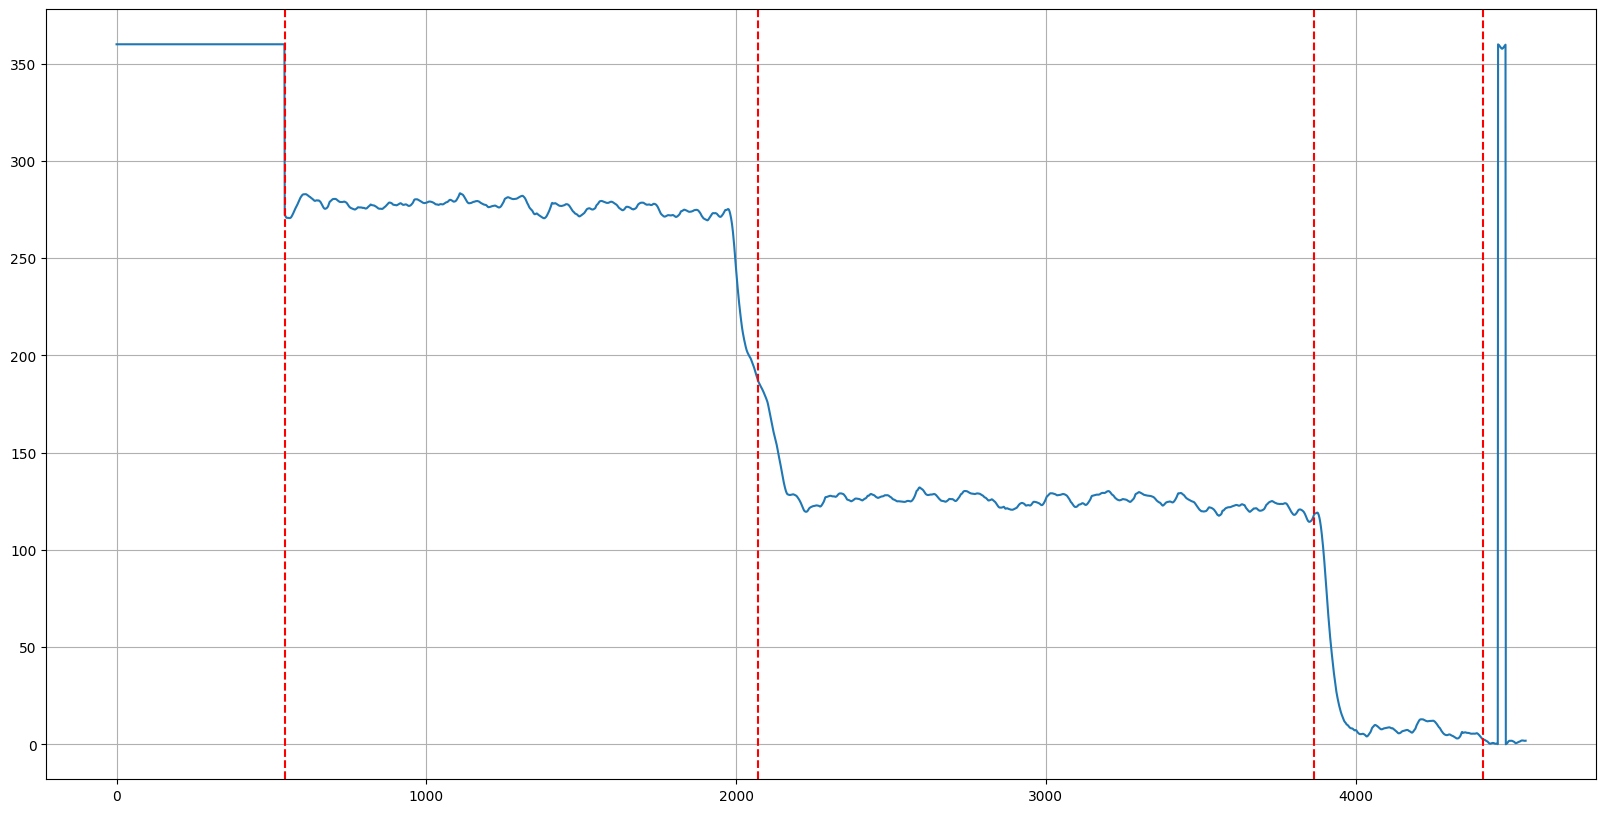

In [20]:
# visulaising the data for gyro to get heading the redlines are the ground truth turns at sample index(they indicate when the turns happened)
fig,ax= plt.subplots(figsize=(20,10))
changes= df_1.index[df_1['direction_change']==1]
plt.plot(df_1['gryo_readings'])
for change in changes:
    ax.axvline(x=change,linestyle='--',color='red')
plt.grid()
plt.show()

+ these values are almost correct

##  Gyroscope-Based Heading Visualization with Direction Changes

This plot shows the estimated heading over time based solely on gyroscope data. It also marks known or detected direction change points using red dashed vertical lines.

###  What’s Being Plotted

- The blue line represents the integrated heading from the gyroscope z-axis (`gyro_z`), stored in the column `gryo_readings`.
- Red dashed lines indicate time indices where a direction change was detected (from `df_1['direction_change'] == 1`).

###  Key Observations

- The heading updates gradually, reflecting rotation over time as sensed by the gyroscope.
- The heading is wrapped to stay within [0, 360) degrees.
- A manual correction was applied for the first 543 samples to align with the peak value — as the sensor started mid-motion and experienced little initial bias so we normalised it.

 

>> This visualization helps verify that heading changes align with expected turning points and can be used to cross-check magnetometer-based or fused sensor estimates. This was the best possible heading we recived with sensor fusion with the gyro readings.


# Complementary filter

>We intended on perfecting the gyro reading with our complimentary filter even more but we didn't really succed with this appraoch and the normal fused gyro reading were better. 

In [21]:
# another function with the develpoed complimentary filter

def complementary_filter(gyro_heading, absolute_heading, alpha=0.98):
    fused = np.zeros_like(gyro_heading)
    fused[0] = absolute_heading[0]  # Initialize with magnetometer heading
    
    for i in range(1, len(fused)):
        delta_gyro = gyro_heading[i] - gyro_heading[i-1]      # Change in heading from gyro
        fused[i] = alpha * (fused[i-1] + delta_gyro) + (1 - alpha) * absolute_heading[i]
        fused[i] %= 360  # Wrapping  angle to [0, 360) 
    
    return fused

+ alpha = 0.98 gives 98% weight to the gyroscope (short-term smoothness), and 2% to the magnetometer (long-term correction).

+ The filter helps correct gyro drift using absolute compass heading, while preserving responsiveness to quick turns.

+ The result is stored in final_theta_corrected, which can now be used for reliable heading-based motion analysis or direction-aware tasks.

In [22]:
# Apply the filter using gyro and smoothed magnetometer headings
df_1['final_theta_corrected']=complementary_filter(df_1['gryo_readings'], df_1['smooth_theta'],alpha=0.98)

### plots and results

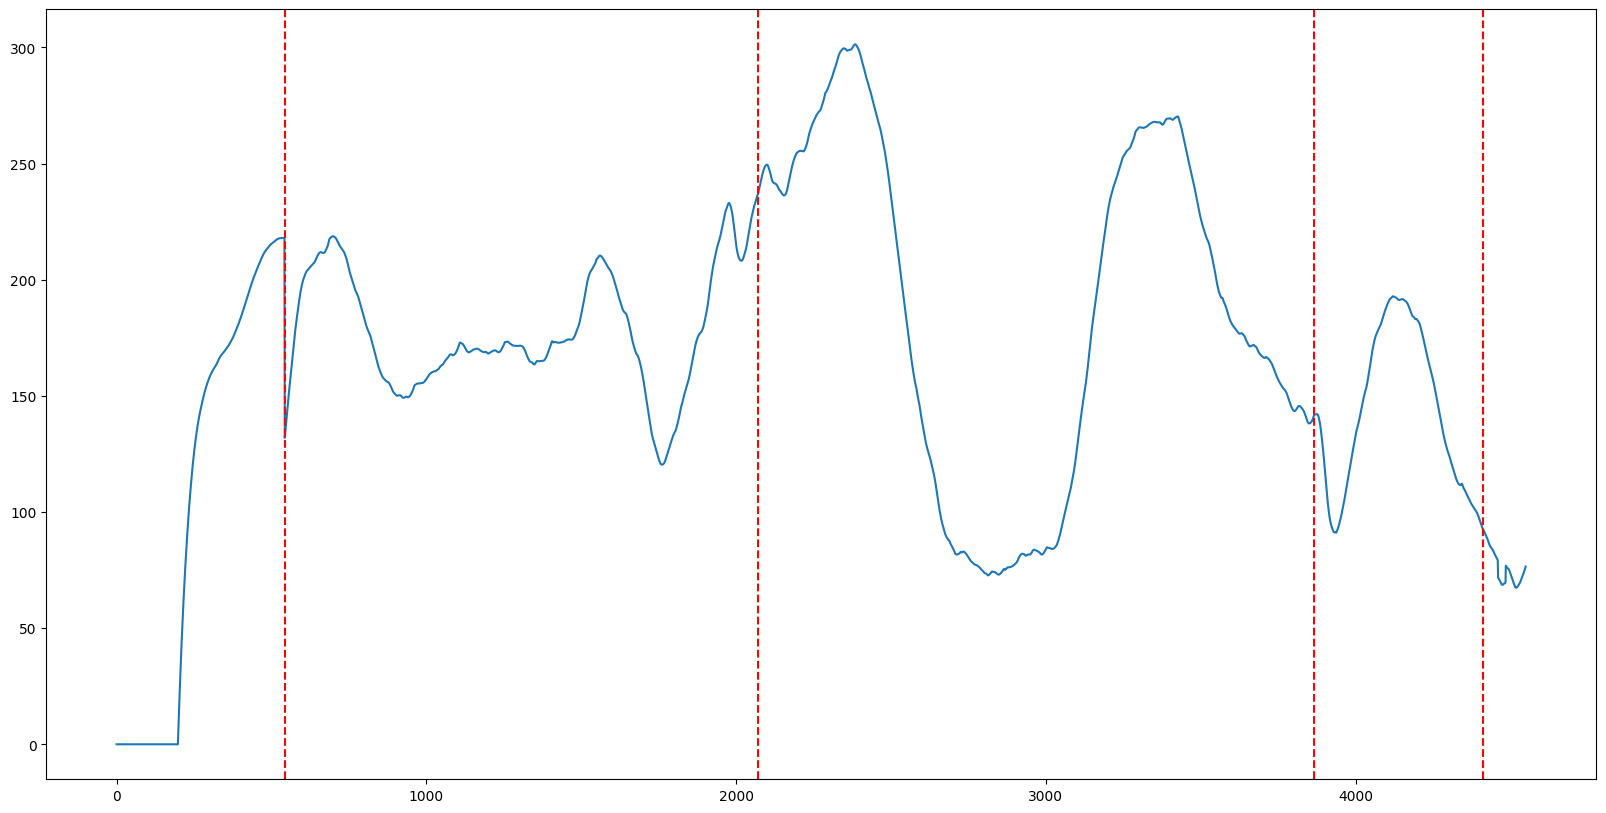

In [23]:
#  visualizing the complementary filter after the sensor fusuion with the gyro 
fig,ax= plt.subplots(figsize=(20,10))
changes= df_1.index[df_1['direction_change']==1]
plt.plot(df_1['final_theta_corrected'])
for change in changes:
    ax.axvline(x=change,linestyle='--',color='red')

plt.show()


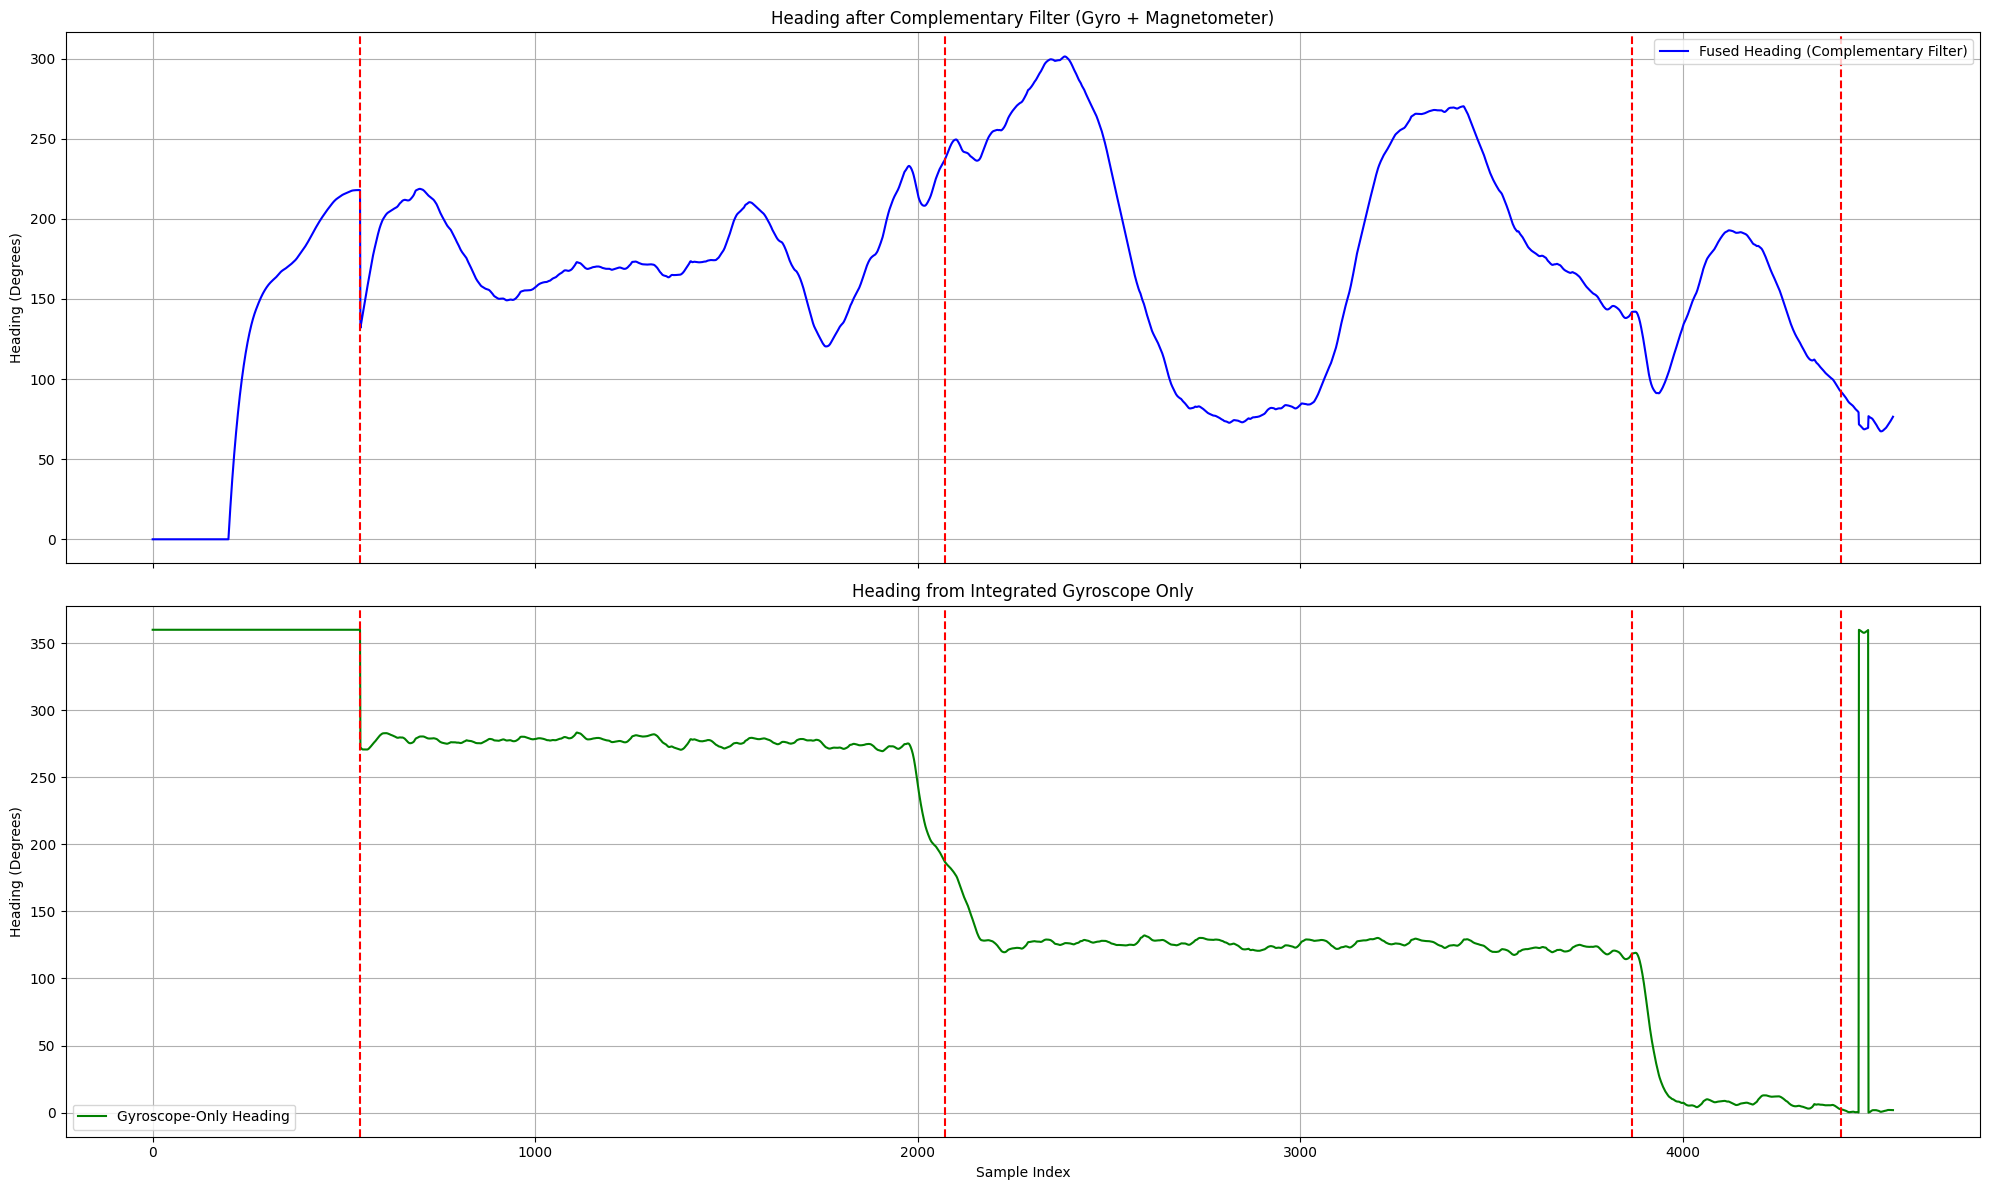

In [24]:


# Get direction change indices
changes = df_1.index[df_1['direction_change'] == 1]

# Create a figure with two subplots (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# --- Plot 1: Complementary Filter Output ---
axes[0].plot(df_1['final_theta_corrected'], label='Fused Heading (Complementary Filter)', color='blue')
for change in changes:
    axes[0].axvline(x=change, linestyle='--', color='red')
axes[0].set_title('Heading after Complementary Filter (Gyro + Magnetometer)')
axes[0].set_ylabel('Heading (Degrees)')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Raw Gyroscope Heading Integration ---
axes[1].plot(df_1['gryo_readings'], label='Gyroscope-Only Heading', color='green')
for change in changes:
    axes[1].axvline(x=change, linestyle='--', color='red')
axes[1].set_title('Heading from Integrated Gyroscope Only')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Heading (Degrees)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


##  Heading Comparison: Complementary Filter vs. Gyroscope Only

This plot compares two heading estimation methods:

---

###  Top Plot: Complementary Filter (Blue)

- Uses magnetometer + gyro integration.
- Smooth but drifts over time  .
- inaccurate near the turns and doesnt help us.

Stored in: `final_theta_corrected`
our approach with the complimentary filter didnt perform well even with various alpha values it was worst compraed to the gyroscope only filter

---

###  Bottom Plot: Gyroscope Only (Green)

- Only Gyro readings.
- Smooth and accurate.
- Aligns well with direction changes.
- More accurate at turns

Stored in: `gryo_readings`

---

Red dashed lines mark detected direction changes.



In [25]:
df_1['final_theta_corrected'][:543].mean().item(),df_1['final_theta_corrected'][543:2072].mean().item(),df_1['final_theta_corrected'][2072:3866].mean().item(),df_1['final_theta_corrected'][3866:4412].mean().item()


(106.05833108797835, 177.92186077536107, 186.8372782935614, 143.1899471357944)

In [26]:
df_1['gryo_readings'][:543].mean().item(),df_1['gryo_readings'][543:2072].mean().item(),df_1['gryo_readings'][2072:3866].mean().item(),df_1['gryo_readings'][3866:4412].mean().item()


(359.9928416485592, 273.23177281321523, 126.89956285358484, 17.880378551260062)

In [27]:
first_angle=df_1['gryo_readings'][:543].mean().item()-df_1['gryo_readings'][543:2072].mean()
secodn_angle= 180-(df_1['gryo_readings'][543:2072].mean().item()-df_1['gryo_readings'][2072:3866].mean().item())
third_angle=180-(df_1['gryo_readings'][2072:3866].mean().item()-df_1['gryo_readings'][3866:4412].mean().item())

In [28]:
first_angle=df_1['final_theta_corrected'][:543].mean().item()-df_1['final_theta_corrected'][543:2072].mean()
secodn_angle= 180-(df_1['final_theta_corrected'][543:2072].mean().item()-df_1['final_theta_corrected'][2072:3866].mean().item())
third_angle=180-(df_1['final_theta_corrected'][2072:3866].mean().item()-df_1['final_theta_corrected'][3866:4412].mean().item())

In [29]:
# Comparig the reading at different angle of turns
print(f'Readings from the Complementry angle calculations:')
print(f'    First angle: {first_angle:.2f} | Acutal: 80')
print(f'    second angle: {secodn_angle:.2f} | Acutal: 39')
print(f'    third angle: {third_angle:.2f} | Acutal: 59')

Readings from the Complementry angle calculations:
    First angle: -71.86 | Acutal: 80
    second angle: 188.92 | Acutal: 39
    third angle: 136.35 | Acutal: 59


In [30]:
# Comparig the reading at different angle of turns
print(f'Readings from the magnitometer:')
print(f'    First angle: {first_angle:.2f} | Acutal: 80')
print(f'    second angle: {secodn_angle:.2f} | Acutal: 39')
print(f'    third angle: {third_angle:.2f} | Acutal: 59')

Readings from the magnitometer:
    First angle: -71.86 | Acutal: 80
    second angle: 188.92 | Acutal: 39
    third angle: 136.35 | Acutal: 59


#  Rename column for clarity before exporting

In [31]:
df_1=df_1.rename(columns={'final_theta_corrected':'complementary_theta'})
df_1.to_csv('imu_updated.csv') # and saving the processed columns to the main csv imu.csv

### RSSI and distance values



For Rssi path loss model and assumptions for understanding how we got the distance columns please refer to rssi_model.ipynb file. which has the explanation for path los components

In [32]:
def convert_rssi_to_distance(df, rssi_column, rssi_at_1m=-69, path_loss_exponent=2.0, new_column_name=None):
    """
    Convert RSSI values to estimated distances using the log-distance path loss model.

    Parameters:
    - df: pandas DataFrame
    - rssi_column: name of the column with RSSI values (string)
    - rssi_at_1m: reference RSSI value at 1 meter (float)
    - path_loss_exponent: environment factor, default is 2.0 (free space)
    - new_column_name: optional name for the output column (string). If None, will default to 'distance_from_' + rssi_column

    Returns:
    - df with a new column for estimated distances
    """
    if new_column_name is None:
        new_column_name = f'distance_from_{rssi_column}'

    df[new_column_name] = 10 ** ((rssi_at_1m - df[rssi_column]) / (10 * path_loss_exponent))
    return df

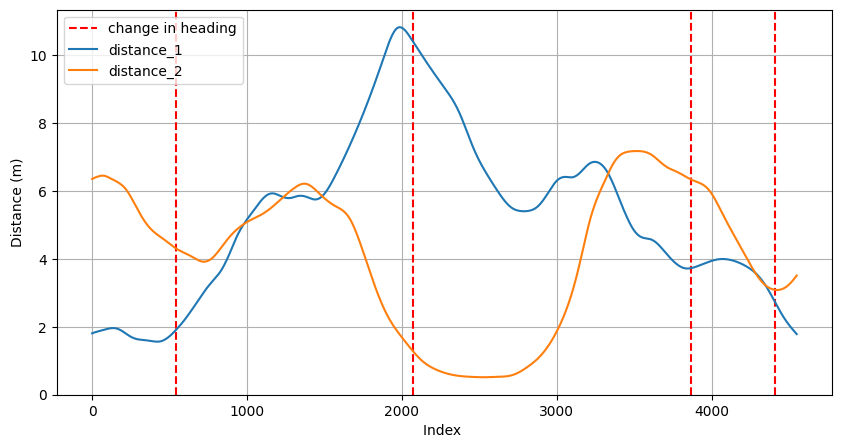

In [33]:
#plotting the distance values from the two beacons which we used 

df_2.columns
ax.axvline(x=change,linestyle='--',color='red')

fig, ax = plt.subplots(figsize=(10, 5))

for i, change in enumerate(changes):
    if i == 0:
        ax.axvline(x=change, linestyle='--', color='red', label='change in heading')
    else:
        ax.axvline(x=change, linestyle='--', color='red')

ax.plot(df_2['distance_rssi_1'], label='distance_1')
ax.plot(df_2['distance_rssi_2'], label='distance_2')  # fixed label here too
ax.legend()
ax.set_xlabel('Index ')
ax.set_ylabel('Distance (m)')
ax.grid()
plt.show()


As the above graph we can clearly see the distance values and correlate  that the the distance when we were at the center of the map at sample index  aprx 2000 we can see the distance being inversely proportional to each other which means our approximations are good with the rsssi values which we used above.

# Working with the step detetcion and motion and movement model for localisation with heading  

In [34]:
Fdf_1 = df_1.copy()
Fdf_1 = Fdf_1.drop(columns=['direction_change','complementary_theta','dt','smooth_theta']) 


In [36]:
# This function was developed with the help of gpts guidance

def hybrid_step_detection(signal, 
                          threshold=1.2, 
                          min_interval=0.3, 
                          sampling_rate=50, 
                          prominence=0.1,
                          smooth=True, 
                          smooth_sigma=1.0):
    """
    Step detection combining manual thresholding and scipy find_peaks with optional smoothing.

    Parameters:
    - signal: 1D numpy array or pandas Series (acc magnitude)
    - threshold: minimum height of a peak to be considered a step
    - min_interval: minimum time between steps (in seconds)
    - sampling_rate: data sampling rate in Hz
    - prominence: prominence of peak (useful for noise robustness)
    - smooth: whether to smooth signal
    - smooth_sigma: standard deviation for Gaussian smoothing

    Returns:
    - step_count: total number of detected steps
    - peak_indices: list of indices where steps occurred
    """
    if smooth:
        signal = gaussian_filter1d(signal, sigma=smooth_sigma)

    # Use scipy's peak finding with your conditions
    min_distance = int(min_interval * sampling_rate)
    peak_indices, props = find_peaks(signal, 
                                     height=threshold, 
                                     distance=min_distance, 
                                     prominence=prominence)

    return len(peak_indices), peak_indices

+ signal: The acceleration signal (e.g., acc or RSSI magnitude).

+ threshold: Minimum peak height to count as a step.
 
+ min_interval: Minimum time between steps (e.g., 0.3 seconds).

+ sampling_rate: Frequency of your data (e.g., 50 Hz).
 
+ prominence: Controls how prominent a peak must be to count (helps ignore noise).

+ smooth: If True, applies Gaussian smoothing.
 
+ smooth_sigma: Controls the degree of smoothing.

In [37]:
# Applying the step hybrid_step_detection function to get the peaks 

steps, peak_indices = hybrid_step_detection(
    Fdf_1['acc'], 
    threshold=11, 
    min_interval=0.4, 
    sampling_rate=50, 
    prominence=0.1,
    smooth=True,
    smooth_sigma=1.05
)

print("Steps detected:", steps)



Steps detected: 60


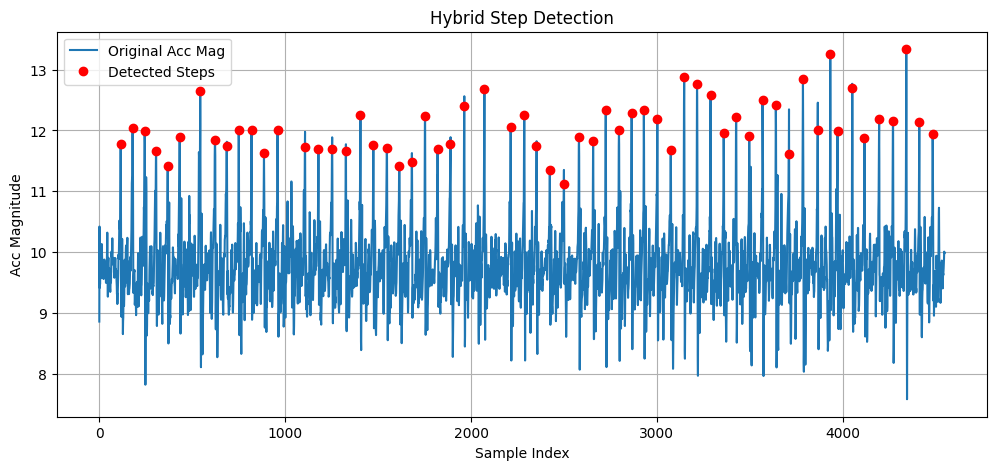

In [38]:
# Plotting the result after using the hybrid step detetction custom made function

plt.figure(figsize=(12, 5))
plt.plot(Fdf_1['acc'], label='Original Acc Mag')
plt.plot(peak_indices, Fdf_1['acc'].iloc[peak_indices], 'ro', label='Detected Steps')
plt.title('Hybrid Step Detection')
plt.xlabel('Sample Index')
plt.ylabel('Acc Magnitude')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
step_events = [
    {
        'index': i,
        'heading': np.deg2rad(Fdf_1.iloc[i]['gryo_readings']),  # must be in radians
        'distance1': df_2.iloc[i]['distance_rssi_1'],
        'distance2': df_2.iloc[i]['distance_rssi_2']
    }
    for i in peak_indices
]


---
---

Some Globals and helper functions

In [40]:
def create_map_mask(polygon, width, height):
    mask = np.zeros((height, width), dtype=np.uint8)
    pts = np.array(polygon, np.int32).reshape((-1,1,2))
    cv2.fillPoly(mask, [pts], 1)
    return mask

In [41]:
# Globals 
# === Constants & Units ===
PIXELS_PER_METER   = 600 / 13.9   # ≈43.165 px per meter
REAL_STEP_LENGTH_M = 0.70         # meters per step
STEP_LENGTH_PX     = REAL_STEP_LENGTH_M * PIXELS_PER_METER

 
# === Ground Truth & Beacon Offsets ===
ground_truth_path = [
    (400, 676),
    (161, 678),
    (540, 150),
    (670, 681),
    (529, 684),
]

# we are using offsets as there was periodical drift in the raw readings but it was minimal to -10 to 20 degres 
# and we corrected this using the below offsets
HEADING_OFFSETS = [(600, -20), (2400, 0), (3800, -10)]


---

# The particle Filter  class


---

 
### 🔹 Particle Class

Represents a single hypothesis of the user's location.

- `__init__(x, y, heading)`: Initializes position and orientation.
- `move(step_length, heading, map_mask)`: Moves the very  particle forward with some noise, checks if the new position is valid (i.e., not inside a wall).
- `clone()`: Returns a copy of the particle (used for uniform resampling). 

---

In [42]:
class Particle:
    def __init__(self, x, y, heading):
        """
        Initialize a particle with position (x, y) and heading (orientation in radians).
        Each particle also has a weight, representing its likelihood (default = 1.0).
        """
        self.x = x
        self.y = y
        self.heading = heading
        self.weight = 1.0

    def move(self, step_length, heading, map_mask):
        """
        Move the particle forward by step_length using a noisy version of the heading.
        Only update position if the new location is inside the valid area of the map.
        
        Parameters:
        - step_length: distance to move (e.g., from step detection)
        - heading: estimated global heading (in radians)
        - map_mask: 2D array (binary image) where True = free space, False = wall
        """
        # Add Gaussian noise to the heading for realism
        noisy_h = heading + np.random.normal(scale=0.1)
        
        # Compute new (x, y) position based on noisy heading
        nx = self.x + step_length * math.cos(noisy_h)
        ny = self.y + step_length * math.sin(noisy_h)

        # Check if new position is within map bounds and not inside a wall
        h, w = map_mask.shape
        ix, iy = int(nx), int(ny)
        if 0 <= ix < w and 0 <= iy < h and map_mask[iy, ix]:
            self.x, self.y, self.heading = nx, ny, noisy_h  # Update particle

    def clone(self):
        """
        Create and return a copy of the particle (used in uniform resampling).
        """
        return Particle(self.x, self.y, self.heading)


---

  

### 🔸 ParticleFilter Class

Manages a collection of particles and performs the filtering operations.

- `initialize(start_point, spread)`: Spawns particles around a known location with some spread partciles far away from one particle.
- `move(step_length, heading, map_mask)`: Moves all particles using given step length and some which we can set noisy heading.
- `evaluate(d1, d2, a1, a2)`: Computes each particle’s weight based on how well its estimated distances to two anchors. Basically,using probability to see the likelihood of the distance measurements. we then also multiply the distnce data and imu data to get the weights(Likelihood or estimations). then we normalize weights
- `resample()`: Keeps more likely particles (high weight) in our case 0.2(which is top 20% of the particles) and then we fill rest by cloning particles with noise for diversity in particles.(THis apprach is also called Multinomial resampling)
- `resample_uniform()`: Randomly clones existing particles to maintain population (used in degenerate cases). 
- `kill_in_walls(map_mask)`: Discards particles that end up in walls or invalid map regions. and keeps only that are valid and which are inside the maps
- `estimate()`: Returns the mean (x, y) position of all particles — the final estimated position,we average the position of all particles and give a best guess or likelihood or estimation to where our current position is. 

---




In [44]:
class ParticleFilter:
    def __init__(self, num_particles=150):
        """
        Initialize the particle filter with a given number of particles.
        """
        self.num_particles = num_particles
        self.particles = []  # List to store Particle objects

    def initialize(self, start_point, spread=2.0):
        """
        Initialize particles around a starting point (cx, cy).
        Each particle has a random heading and position based on Gaussian noise.

        Parameters:
        - start_point: (x, y) tuple representing the initial position
        - spread: standard deviation for the random initialization
        """
        cx, cy = start_point
        self.particles = [
            Particle(
                x=np.random.normal(cx, spread),  # add positional noise
                y=np.random.normal(cy, spread),
                heading=np.random.uniform(-math.pi, math.pi)  # random orientation
            )
            for _ in range(self.num_particles)
        ]

    def move(self, step_length, heading, map_mask):
        """
        Move all particles based on step length and current heading.

        Parameters:
        - step_length: distance moved
        - heading: estimated direction of motion
        - map_mask: binary map (1 = walkable, 0 = wall)
        """
        for p in self.particles:
            p.move(step_length, heading, map_mask)

    def evaluate(self, d1, d2, a1, a2, base_std=5):
        """
        Assign weights to particles based on their proximity to anchor points.

        Parameters:
        - d1, d2: measured distances (e.g., from RSSI) to anchors a1 and a2
        - a1, a2: coordinates of anchor points
        - base_std: standard deviation scaling for Gaussian likelihood
        """
        total = d1 + d2 + 1e-6  # avoid divide by zero
        w1 = d2 / total  # weight for anchor 1
        w2 = d1 / total  # weight for anchor 2

        for p in self.particles:
            # Compute distance from particle to each anchor
            dist1 = math.hypot(p.x - a1[0], p.y - a1[1])
            dist2 = math.hypot(p.x - a2[0], p.y - a2[1])

            # Assign likelihood based on how close particle's distance matches measured distance
            p.weight = (
                norm.pdf(d1, loc=dist1, scale=base_std * w1) *
                norm.pdf(d2, loc=dist2, scale=base_std * w2)
            )

        # Normalize weights so they sum to 1
        s = sum(p.weight for p in self.particles)
        if s > 0:
            for p in self.particles:
                p.weight /= s
        else:
            # In case all weights are zero, assign equal weight
            for p in self.particles:
                p.weight = 1.0 / len(self.particles)

    def resample(self):
        """
        Resample particles based on their weights.
        Particles with higher weights are more likely to be chosen.
        this appraoch is also called multinomial resampling
        """
        weights = np.array([p.weight for p in self.particles])

        if weights.sum() == 0:
            weights = np.ones_like(weights) / len(weights)  # uniform if degenerate

        # Randomly select particle indices based on weights
        idxs = np.random.choice(len(self.particles), size=len(self.particles), p=weights)

        new = []
        for i in idxs:
            old = self.particles[i]
            # Add slight noise to avoid particle collapse
            p = Particle(old.x + np.random.normal(scale=0.2),
                         old.y + np.random.normal(scale=0.2),
                         old.heading)
            p.weight = old.weight
            new.append(p)

        self.particles = new  # Replace old particle set

    def resample_uniform(self):
        """
        Uniformly clone particles to refresh diversity (useful during initialization or reset).
        """
        clones = [p.clone() for p in self.particles]

        while len(clones) < self.num_particles:
            clones.append(np.random.choice(self.particles).clone())

        self.particles = clones[:self.num_particles]

    def kill_in_walls(self, map_mask):
        """
        Remove particles that have landed inside walls or out-of-bounds.

        Parameters:
        - map_mask: 2D binary array representing valid floor space
        """
        h, w = map_mask.shape
        self.particles = [
            p for p in self.particles
            if 0 <= int(p.x) < w and 0 <= int(p.y) < h and map_mask[int(p.y), int(p.x)]
        ]

    def estimate(self):
        """
        Compute the average position of all particles — used as the current location estimate.

        Returns:
        - (x_mean, y_mean): estimated coordinates of the user
        """
        xs = [p.x for p in self.particles]
        ys = [p.y for p in self.particles]
        return float(np.mean(xs)), float(np.mean(ys))


---

###   Workflow Summary

1. Initialize particles around a known start.
2. On each step:
   - Move particles based on step + heading.
   - Reweight based on signal distances.
   - Resample particles based on weights.
   - Remove invalid particles.
   - Estimate position as the average of all valid particles.

This method allows robust tracking of a person or object even with noisy sensor inputs.

---

Now for the demonstarion of particles filter 
> For Visualisation pygame was used to run the particle filter 

there are as below

+ Custom Map with using Rssi values

+ Custom map without using the RSSI 

+ without any map 

so we are implementing with/without map and also with/without RSSI values


---

In [45]:
# This is for the video generation 

# # %pip install imageio[ffmpeg]

# import imageio
# from pygame import surfarray

Code below is for Map and Rssi 

In [46]:
# === Pygame Setup (With MAP and Rssi) ===
pygame.init()
WIDTH, HEIGHT = 800, 800
screen = pygame.display.set_mode((WIDTH, HEIGHT))  # create the window
pygame.display.set_caption("Particle Filter Distance Viz")
clock = pygame.time.Clock()
font  = pygame.font.SysFont("Arial", 18)

# === Color Setup ===
# Defines colors for different objects on screen
BG_COLOR = (34, 34, 34)  # Background
GRID_COLOR = (64, 64, 64)  # Grid lines
MAP_FILL = (48, 63, 83)  # Map area
MAP_BORDER = (26, 35, 46)  # Map outline
ANCHOR_COLOR = (255, 193, 7)  # RSSI anchor beacons
MEAS1_COLOR, MEAS2_COLOR = (240, 98, 146), (100, 181, 246)  # Distance rings
HALO1_COLOR, HALO2_COLOR = (255, 87, 34), (156, 39, 176)  # Best-matching particles
PARTICLE_COLOR = (189, 189, 189)
EST_PATH_COLOR = (233, 30, 99)
GROUND_TRUTH_COLOR = (0, 230, 118)
GROUND_TRUTH_PT_COLOR = (0, 200, 83)
TEXT_COLOR = (200, 200, 200)

# === Map Setup ===
triangle = [(700,700), (100,700), (550,100)]  # Walkable area as a triangle
map_mask = create_map_mask(triangle, WIDTH, HEIGHT)  # Binary mask for collision
anchor1 = np.array([541.0, 138.0])  # Anchor point 1 (top)
anchor2 = np.array([438.0, 678.0])  # Anchor point 2 (bottom-left)

# === Particle Filter Initialization ===
pf = ParticleFilter(num_particles=150)
pf.initialize(start_point=(450.0, 678.0), spread=2.0)  # Random particles around start

# Tracking lists
est_positions = []  # Estimated positions for path visualization
best_b1 = []  # Best particles relative to anchor 1
best_b2 = []  # Best particles relative to anchor 2
TOP_K = 5  # Number of top particles to highlight

# === Prepare Step Events ===
# Each step has: step index, heading (from gyro), and distance estimates (from RSSI)
step_events = [
    {
        'index': i,
        'heading': np.deg2rad(Fdf_1.iloc[i]['gryo_readings']),
        'dist1':   df_2.iloc[i]['distance_rssi_1'],
        'dist2':   df_2.iloc[i]['distance_rssi_2']
    }
    for i in peak_indices
]

# === Simulation Loop ===
idx = 0
running = True

# video_frames = []


while running:
    # Handle quit event
    for e in pygame.event.get():
        if e.type == pygame.QUIT:
            running = False

    # Draw background and grid
    # (the background and grid was enhanced with help of Chatgpt for drwaing in py game as we prompted the measurements )

    
    screen.fill(BG_COLOR)
    for x in range(0, WIDTH, 40):
        pygame.draw.line(screen, GRID_COLOR, (x, 0), (x, HEIGHT))
    for y in range(0, HEIGHT, 40):
        pygame.draw.line(screen, GRID_COLOR, (0, y), (WIDTH, y))

    # Draw the walkable map area
    pygame.draw.polygon(screen, MAP_FILL, triangle)
    pygame.draw.polygon(screen, MAP_BORDER, triangle, 4)

    # Draw the two anchor points
    pygame.draw.circle(screen, ANCHOR_COLOR, anchor1.astype(int), 8)
    pygame.draw.circle(screen, ANCHOR_COLOR, anchor2.astype(int), 8)

    # === Perform a filter update if steps remain ===
    if idx < len(step_events):
        ev = step_events[idx]

        # Draw the RSSI distance rings (circles) around each anchor
        r1 = int(ev['dist1'] * PIXELS_PER_METER)
        r2 = int(ev['dist2'] * PIXELS_PER_METER)
        pygame.draw.circle(screen, MEAS1_COLOR, anchor1.astype(int), r1, 1)
        pygame.draw.circle(screen, MEAS2_COLOR, anchor2.astype(int), r2, 1)

        # Adjust heading with any manual offsets as there was some drift so we are using some offsets to correct the heading a little bit
        off = 0
        for th, o in HEADING_OFFSETS:
            if ev['index'] >= th:
                off = o
        head = ev['heading'] + math.radians(off)



        # === Particle Filter Update ===
        # This is where we implement our particle filter we move evaluate and resample and also kill particles here

        pf.move(STEP_LENGTH_PX, head, map_mask)  # Move particles
        pf.evaluate(ev['dist1'], ev['dist2'], anchor1, anchor2)  # Reweight based on distance likelihood
        pf.resample()  # Resample based on weights
        pf.kill_in_walls(map_mask)  # Discard particles in walls



        # Estimate positions from particle cloud

        ex, ey = pf.estimate()
        est_positions.append((ex, ey))

        # Find top K best-matching particles to each beacon (we are doing this for deteting the best estimated particles from the two beacons)
        diffs1 = sorted(
            [(p, abs(math.hypot(p.x - anchor1[0], p.y - anchor1[1]) - ev['dist1']))
             for p in pf.particles],
            key=lambda x: x[1]
        )[:TOP_K]
        diffs2 = sorted(
            [(p, abs(math.hypot(p.x - anchor2[0], p.y - anchor2[1]) - ev['dist2']))
             for p in pf.particles],
            key=lambda x: x[1]
        )[:TOP_K]
        best_b1 = [p for p, _ in diffs1]
        best_b2 = [p for p, _ in diffs2]

        idx += 1  # Advance to next step event or step which we have taken

    # === Draw Pulsing Halos Around Best-Matching Particles ===

    # We are also marking pulsating rings around the best particles being estimated with respect to two beacons or anchors


    t = pygame.time.get_ticks() / 1000.0  # animation time
    pulse = 4 + 2 * math.sin(2 * math.pi * 1.5 * t)
    alpha1 = int(180 + 75 * math.sin(2 * math.pi * 1.0 * t))
    alpha2 = int(180 + 75 * math.sin(2 * math.pi * 1.2 * t))
    halo_surf = pygame.Surface((WIDTH, HEIGHT), pygame.SRCALPHA)

    for p in best_b1:
        pygame.draw.circle(
            halo_surf,
            (*HALO1_COLOR, alpha1),
            (int(p.x), int(p.y)),
            int(pulse) + 6,
            2
        )
    for p in best_b2:
        pygame.draw.circle(
            halo_surf,
            (*HALO2_COLOR, alpha2),
            (int(p.x), int(p.y)),
            int(pulse) + 6,
            2
        )
    screen.blit(halo_surf, (0, 0))

    # === Draw All Particles ===
    for p in pf.particles:
        pygame.draw.circle(screen, PARTICLE_COLOR, (int(p.x), int(p.y)), 3)

    # === Draw Estimated Path (fused result) ===
    if len(est_positions) > 1:
        pts = [(int(x), int(y)) for x, y in est_positions]
        pygame.draw.lines(screen, EST_PATH_COLOR, False, pts, 2)

    # === Draw Ground Truth Path ===
    pygame.draw.lines(screen, GROUND_TRUTH_COLOR, False, ground_truth_path, 3)
    for pt in ground_truth_path:
        pygame.draw.circle(screen, GROUND_TRUTH_PT_COLOR, pt, 5)




    # === Draw Legend === 
    # 
    # (The Legend was enhanced with Chatgpt for better readability)


    lx, ly, sp = 10, 10, 20  # Legend start position and spacing
    pygame.draw.line(screen, GROUND_TRUTH_COLOR, (lx, ly), (lx+30, ly), 3)
    screen.blit(font.render("Ground Truth", True, TEXT_COLOR), (lx+40, ly-8))

    pygame.draw.line(screen, EST_PATH_COLOR, (lx, ly+sp), (lx+30, ly+sp), 3)
    screen.blit(font.render("Estimated Path", True, TEXT_COLOR), (lx+40, ly+sp-8))

    pygame.draw.circle(screen, MEAS1_COLOR, (lx+15, ly+2*sp), 5)
    screen.blit(font.render("Range Circle 1", True, TEXT_COLOR), (lx+40, ly+2*sp-8))

    pygame.draw.circle(screen, MEAS2_COLOR, (lx+15, ly+3*sp), 5)
    screen.blit(font.render("Range Circle 2", True, TEXT_COLOR), (lx+40, ly+3*sp-8))

    pygame.draw.circle(screen, HALO1_COLOR, (lx+15, ly+4*sp), 5)
    screen.blit(font.render("Top b1 matches", True, TEXT_COLOR), (lx+40, ly+4*sp-8))

    pygame.draw.circle(screen, HALO2_COLOR, (lx+15, ly+5*sp), 5)
    screen.blit(font.render("Top b2 matches", True, TEXT_COLOR), (lx+40, ly+5*sp-8))


    pygame.draw.circle(screen, ANCHOR_COLOR, (lx+15, ly+6*sp), 5)
    screen.blit(font.render("BEACONS", True, TEXT_COLOR), (lx+40, ly+6*sp-8))


        # === Top-right Caption ===
    caption_font = pygame.font.SysFont("Arial", 20, bold=True)
    caption_text = caption_font.render("With Map and RSSI", True, TEXT_COLOR)
    screen.blit(caption_text, (WIDTH - caption_text.get_width() - 10, 10))


    # === Update the screen ===
    pygame.display.flip()
    clock.tick(6)  # Cap the frame rate

    # frame_surface = pygame.display.get_surface()
    # frame_array = pygame.surfarray.array3d(frame_surface)
    # frame_array = frame_array.swapaxes(0, 1)
    # video_frames.append(frame_array.copy())


# print("Saving video to 'pf_animation.mp4'...")
# imageio.mimsave("noise_with_0.01_animation.mp4", video_frames, fps=5)
# print("Video saved.")
# Cleanup
pygame.quit()



# Code below is without Rssi

In [47]:
# === Pygame Setup (No RSSI) ===
pygame.init()
WIDTH, HEIGHT = 800, 800
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Particle Filter - No RSSI")
clock = pygame.time.Clock()
font = pygame.font.SysFont("Arial", 18)



# === Theme Colors (Dark Mode) ===
BG_COLOR              = (34, 34, 34)     # Background color
GRID_COLOR            = (64, 64, 64)     # Grid lines
MAP_FILL              = (48, 63, 83)     # Map interior
MAP_BORDER            = (26, 35, 46)     # Map edge
ANCHOR_COLOR          = (255, 193, 7)    # Anchors (not used, shown for reference)
PARTICLE_COLOR        = (189, 189, 189)  # All particles
EST_PATH_COLOR        = (233, 30, 99)    # Estimated path
GROUND_TRUTH_COLOR    = (0, 230, 118)    # Ground truth path
GROUND_TRUTH_PT_COLOR = (0, 200, 83)     # Ground truth points
HALO_COLOR            = (255, 87, 34)    # Halo around estimated point
TEXT_COLOR            = (200, 200, 200)  # UI text

# === Map Setup ===
# (map was setup with the help of chatgpt )


triangle = [(700,700), (100,700), (550,100)]  # Polygonal map area
map_mask = create_map_mask(triangle, WIDTH, HEIGHT)  # Valid area mask
anchor1  = np.array([541.0, 138.0])  # Optional reference anchors
anchor2  = np.array([438.0, 678.0])



# === Particle Filter Initialization ===
pf = ParticleFilter(num_particles=150)
pf.initialize(start_point=(450.0, 678.0), spread=4.0)  # Particles start near bottom center
est_positions = []  # To store estimated path

# === Main Loop ===
running = True
idx = 0  # Step counter

# video_frames = []

while running:
    for e in pygame.event.get():
        if e.type == pygame.QUIT:
            running = False

    # === Draw Background and Grid ===
    screen.fill(BG_COLOR)
    for x in range(0, WIDTH, 40):
        pygame.draw.line(screen, GRID_COLOR, (x, 0), (x, HEIGHT))
    for y in range(0, HEIGHT, 40):
        pygame.draw.line(screen, GRID_COLOR, (0, y), (WIDTH, y))

    # === Draw Map and Anchors ===
    pygame.draw.polygon(screen, MAP_FILL, triangle)
    pygame.draw.polygon(screen, MAP_BORDER, triangle, 4)
    pygame.draw.circle(screen, ANCHOR_COLOR, anchor1.astype(int), 8)
    pygame.draw.circle(screen, ANCHOR_COLOR, anchor2.astype(int), 8)

    # === Particle Filter Update (no RSSI) ===
    if idx < len(step_events):
        ev = step_events[idx]
        head = ev['heading']

        # Apply heading correction offset if needed
        for th, off in HEADING_OFFSETS:
            if ev['index'] >= th:
                head += math.radians(off)

        # Move particles using only heading and step length
        pf.move(STEP_LENGTH_PX, head, map_mask)
        pf.kill_in_walls(map_mask)           # Remove particles in invalid areas
        pf.resample_uniform()                # Uniformly clone particles as now  we dont have rssi values we are using random uniform values in resample the particles
        ex, ey = pf.estimate()               # Average particle position
        est_positions.append((ex, ey))       # Store estimated position
        idx += 1

    # === Draw Particles ===
    for p in pf.particles:
        pygame.draw.circle(screen, PARTICLE_COLOR, (int(p.x), int(p.y)), 3)

    # === Draw Estimated Path ===
    if len(est_positions) > 1:
        pts = [(int(x), int(y)) for x, y in est_positions]
        pygame.draw.lines(screen, EST_PATH_COLOR, False, pts, 2)

    # === Draw Pulsing Halo at Current Estimate ===
    if est_positions:
        x, y = est_positions[-1]
        t = pygame.time.get_ticks() / 1000.0
        radius = 8 + 4 * math.sin(2 * math.pi * 1.5 * t)
        alpha  = int(128 + 127 * math.sin(2 * math.pi * 1.0 * t))
        halo = pygame.Surface((WIDTH, HEIGHT), pygame.SRCALPHA)
        pygame.draw.circle(
            halo,
            (*HALO_COLOR, alpha),
            (int(x), int(y)),
            int(radius),
            2
        )
        screen.blit(halo, (0, 0))

    # === Draw Ground Truth ===
    pygame.draw.lines(screen, GROUND_TRUTH_COLOR, False, ground_truth_path, 3)
    for pt in ground_truth_path:
        pygame.draw.circle(screen, GROUND_TRUTH_PT_COLOR, pt, 5)

    # === Legend (Bottom-Left) ===
    lx, ly, sp = 10, 10, 20
    pygame.draw.line(screen, GROUND_TRUTH_COLOR, (lx, ly), (lx+30, ly), 3)
    screen.blit(font.render("Ground Truth", True, TEXT_COLOR), (lx+35, ly-8))
    pygame.draw.line(screen, EST_PATH_COLOR, (lx, ly+sp), (lx+30, ly+sp), 3)
    screen.blit(font.render("Estimated Path", True, TEXT_COLOR), (lx+35, ly+sp-8))
    pygame.draw.circle(screen, PARTICLE_COLOR, (lx+15, ly+2*sp), 5)
    screen.blit(font.render("Particles", True, TEXT_COLOR), (lx+35, ly+2*sp-8))

    pygame.draw.circle(screen, ANCHOR_COLOR, (lx+15, ly+3*sp), 5)
    screen.blit(font.render("BEACONS", True, TEXT_COLOR), (lx+40, ly+3*sp-8))

    # === Caption in Top-Right ===
    caption_font = pygame.font.SysFont("Arial", 20, bold=True)
    caption_text = caption_font.render("Without RSSI", True, TEXT_COLOR)
    screen.blit(caption_text, (WIDTH - caption_text.get_width() - 10, 10))

    # === Update Display ===
    pygame.display.flip()
    clock.tick(7)   

    # frame_surface = pygame.display.get_surface()
    # frame_array = pygame.surfarray.array3d(frame_surface)
    # frame_array = frame_array.swapaxes(0, 1)
    # video_frames.append(frame_array.copy())

# print("Saving video to 'pf_animation.mp4'...")
# imageio.mimsave("noise_with_0.01_animation.mp4", video_frames, fps=5)
# print("Video saved.")

pygame.quit()


# Code below is for Without map Constarints

In [48]:
# === Particle Filter Visualization (Without Map Constraint) ===

# Initialize Pygame window
pygame.init()
W, H = 800, 800
screen = pygame.display.set_mode((W, H))
pygame.display.set_caption("Particle Filter – Without map")
clock = pygame.time.Clock()
font = pygame.font.SysFont("Arial", 18)

# Define color constants for UI
BG        = (34, 34, 34)      # Background
GRID      = (64, 64, 64)      # Grid lines
ANC       = (255, 193, 7)     # Anchor points
MEAS1_COL = (240, 98, 146)    # Measurement circle 1
MEAS2_COL = (100, 181, 246)   # Measurement circle 2
HALO1     = (255, 87, 34)     # Halo for anchor1 particles
HALO2     = (156, 39, 176)    # Halo for anchor2 particles
PART_COL  = (189, 189, 189)   # Particles
EST_COL   = (233, 30, 99)     # Estimated path color
GT_COL    = (0, 230, 118)     # Ground truth line
GT_PT     = (0, 200, 83)      # Ground truth dots
TXT       = (200, 200, 200)   # Text color

# Anchor positions (fixed beacons)
anchor1 = np.array([541.0, 138.0])
anchor2 = np.array([438.0, 678.0])

# Map mask filled entirely with 1s (no map constraints)
full_mask = np.ones((H, W), dtype=np.uint8)

# === Initialize Particle Filter ===
pf = ParticleFilter(150)
pf.initialize((450.0, 678.0), spread=2.0)

est_path = []  # Store estimated path over time
best1, best2 = [], []  # Best particles matching anchor1/anchor2
idx = 0
running = True



# video_frames = []


# === Main Loop ===
while running:
    for e in pygame.event.get():
        if e.type == pygame.QUIT:
            running = False

    # === Draw background and grid ===
    screen.fill(BG)
    for x in range(0, W, 40):
        pygame.draw.line(screen, GRID, (x, 0), (x, H))
    for y in range(0, H, 40):
        pygame.draw.line(screen, GRID, (0, y), (W, y))

    # Draw anchor points
    pygame.draw.circle(screen, ANC, anchor1.astype(int), 8)
    pygame.draw.circle(screen, ANC, anchor2.astype(int), 8)

    # === Particle Filter Update ===
    if idx < len(step_events):
        ev = step_events[idx]

        # Draw estimated distance circles (from RSSI)
        r1 = int(ev['dist1'] * PIXELS_PER_METER)
        r2 = int(ev['dist2'] * PIXELS_PER_METER)
        pygame.draw.circle(screen, MEAS1_COL, anchor1.astype(int), r1, 1)
        pygame.draw.circle(screen, MEAS2_COL, anchor2.astype(int), r2, 1)

        # Move particles based on heading with correction offset
        off = sum(o for t, o in HEADING_OFFSETS if ev['index'] >= t)
        head = ev['heading'] + math.radians(off)
        pf.move(STEP_LENGTH_PX, head, full_mask)

        # Weight particles based on RSSI distances
        pf.evaluate(ev['dist1'], ev['dist2'], anchor1, anchor2)
        pf.resample()

        # Estimate position and store it
        ex, ey = pf.estimate()
        est_path.append((ex, ey))

        # Select top-k closest particles to each anchor (based on RSSI)
        d1s = sorted(
            [(p, abs(math.hypot(p.x - anchor1[0], p.y - anchor1[1]) - ev['dist1']))
             for p in pf.particles],
            key=lambda x: x[1]
        )[:5]
        d2s = sorted(
            [(p, abs(math.hypot(p.x - anchor2[0], p.y - anchor2[1]) - ev['dist2']))
             for p in pf.particles],
            key=lambda x: x[1]
        )[:5]
        best1 = [p for p, _ in d1s]
        best2 = [p for p, _ in d2s]

        idx += 1

    # === Draw pulsing halos around top-matching particles ===
    t = pygame.time.get_ticks() / 1000
    pulse = 4 + 2 * math.sin(2 * math.pi * 1.5 * t)
    surf = pygame.Surface((W, H), pygame.SRCALPHA)
    a1 = int(180 + 75 * math.sin(2 * math.pi * 1.0 * t))
    a2 = int(180 + 75 * math.sin(2 * math.pi * 1.2 * t))
    for p in best1:
        pygame.draw.circle(surf, (*HALO1, a1), (int(p.x), int(p.y)), int(pulse) + 6, 2)
    for p in best2:
        pygame.draw.circle(surf, (*HALO2, a2), (int(p.x), int(p.y)), int(pulse) + 6, 2)
    screen.blit(surf, (0, 0))

    # === Draw all particles ===
    for p in pf.particles:
        pygame.draw.circle(screen, PART_COL, (int(p.x), int(p.y)), 3)

    # === Draw estimated trajectory ===
    if len(est_path) > 1:
        pts = [(int(x), int(y)) for x, y in est_path]
        pygame.draw.lines(screen, EST_COL, False, pts, 2)

    # === Draw ground truth path ===
    pygame.draw.lines(screen, GT_COL, False, ground_truth_path, 3)
    for pt in ground_truth_path:
        pygame.draw.circle(screen, GT_PT, pt, 5)

    # === Draw Legend ===
    lx, ly, sp = 10, 10, 20
    pygame.draw.line(screen, GT_COL, (lx, ly), (lx+30, ly), 3)
    screen.blit(font.render("Ground Truth", True, TXT), (lx+35, ly-8))
    pygame.draw.line(screen, EST_COL, (lx, ly+sp), (lx+30, ly+sp), 3)
    screen.blit(font.render("Estimated Path", True, TXT), (lx+35, ly+sp-8))
    pygame.draw.circle(screen, PART_COL, (lx+15, ly+2*sp), 5)
    screen.blit(font.render("Particles", True, TXT), (lx+35, ly+2*sp-8))


    pygame.draw.circle(screen, ANCHOR_COLOR, (lx+15, ly+3*sp), 5)
    screen.blit(font.render("BEACONS", True, TEXT_COLOR), (lx+40, ly+3*sp-8))

    # === Caption at top-right ===
    caption_font = pygame.font.SysFont("Arial", 20, bold=True)
    caption_text = caption_font.render("Without Map", True, TXT)
    screen.blit(caption_text, (W - caption_text.get_width() - 10, 10))


    # This is recording the frames ()generated with the guidance of Chatgptgpt

    # frame_surface = pygame.display.get_surface()
    # frame_array = pygame.surfarray.array3d(frame_surface)
    # frame_array = frame_array.swapaxes(0, 1)
    # video_frames.append(frame_array.copy())


    pygame.display.flip()
    clock.tick(10)  # Limit to 10 FPS



# print("Saving video to 'pf_animation.mp4'...")
# imageio.mimsave("noise_with_0.01_animation.mp4", video_frames, fps=5)
# print("Video saved.")
pygame.quit()


---

 

## Our Effect of Hyperparameters on our Particle Filter Performance

### 1. `spread` (initial position noise) The spread TRADE-OFF (Find a sweet spot by trial and error)
- Controls how much the initial particles are scattered around the start location.
- 🔹 Low spread (e.g., 1.0): Particles are tightly packed → faster convergence but more prone to initial bias.
- 🔹 High spread (e.g., 4.0): Particles are more diverse → better for uncertain starting positions, but slower convergence.
>  Trade-off between flexibility and precision.

### 2. `base_std` in `evaluate()` (likelihood noise)
- Determines how much uncertainty you assume in RSSI measurements.
- 🔹 Low std (e.g., 2): Makes the filter very strict about matching measured vs. actual distance → sensitive to noise.
- 🔹 High std (e.g., 8): Allows broader matching → robust to RSSI noise but reduces precision.
> Helps balance trust in measurements vs. model noise.

### 3. `num_particles`
- Defines how many hypotheses (particles) the filter maintains.
- 🔹 Low number (e.g., 50): Faster to compute, but less coverage → may lose track of actual info.
- 🔹 High number (e.g., 300+): Better accuracy and resilience, especially in noisy or ambiguous regions →but  more computation.

> This totally dependson the environment which we are going to use.
> More particles = better exploration, but requires more CPU time.

 

> Fine-tuning these values based on your dataset and sensor noise characteristics is essential for robust performance.


---

 

###   Observations


--- 

1. **With Map + RSSI + Gyro:**
   - The particle filter converges to the ground truth path with high accuracy.
   - Using a map mask(boundaries) significantly improves accuracy by eliminating impossible positions with the help of probability .
   - The estimated path closely follows the ground truth with smooth transitions and we can also the the pulsatingb circles(halos) in the map for best particles.
   - Halo highlights around top-k particles help visualize confidence zones. where we can easily diagnose where the particle filter is looking and 

+ my Key Observation in MAP+ RSSI ()
>>  the pulsating circles confirm that the oparticle filter is accurate as we move towards a beacons it use those particles and at the same time the best particles keep shifting.

2. **Without Map Constraints:**
   - Particles can drift outside the physical space, especially with noisy sensor inputs.
   - the particles left weare not even close to the actual ground truth path and the shape of the path was also totally different.
   - The estimated path can diverge significantly from ground truth without environmental boundaries so we need boundaries for particles for better estimations.

3. **With Step + Gyro Only (No RSSI):**
   - Particle filter can track heading fairly well if gyro readings are accurate.
   - RSSI is not used, so the particle filter relies on step and gyro data only.
   - The estimated path is still not very accurate and the particles are still drifting away from the actual but in real life even the noisy rsssi reading helps significantly to localisationa nd its very important to localize in the given map frame.
   - without rssi it is very difficult to come as close with the ground truth path.
   

4. **With RSSI + Gyro (No Map):**
   - RSSI-based distance circles help guide the particle cloud back on track.
   - But, RSSI noise causes occasional false convergence, but overall the accuracy wasnt that great for some time it does follow the path but then eventually drifts and the gyro readings get noisy without map constarints it gets difficult to localize accurately.
   - Not relaible combination






---

###   What I Learned

- The particle filter is powerful but highly dependent on correct sensor readings and constraint information reagarding the boundaries of the map we set.
- Gyroscope data helps with short-term heading estimation, but long-term drift must be corrected manually.
- RSSI data can anchor positions but is a little noisy and benefits from smoothing and probabilistic weighting.
- Adding map constraints drastically improves localization performance and helps accurately stimate our position.
>> Visualizations using Pygame (particles, halos, range circles) help debug and interpret the behavior intuitively.

>  Combining multiple sensors (IMU + RSSI + Map) through probabilistic filtering gives robust indoor localization, especially when each sensor's limitations are understood and compensated for properly.

---

# References

+ The lecture slides from Embedded Intelligence- by ***Prof. Dr. Ing. Gerald prikl***,OTH amberg-weiden(Used the same style of user defined functions and bulit other function on top of each oher and used the workflow from the slides to proceed further)

+ https://sassafras13.github.io/PF/
(The above link has very simple explanation about particle filter which helped me understand build the concept accordingly)

+ https://pmc.ncbi.nlm.nih.gov/articles/PMC7826670/
(to undersstand the literature i used the above website )

+ https://aleksandarhaber.com/clear-and-concise-particle-filter-tutorial-with-python-implementation-part-3-python-implementation-of-particle-filter-algorithm/
(In the above site i understood the different types of resampling and used multinomial resampling which commonly used approach for small systems) Following github repo--> 
https://github.com/AleksandarHaber/Python-Implementation-of-Particle-Filter


+ https://github.com/rlabbe/filterpy/blob/master/filterpy/monte_carlo/resampling.py
(In this repo i was able to understand the resmapling and usedthe same logic with different variable)

---